# VLA C-band beam validation

This notebook is the executable scientific account of the THOL0001 SPW-4 CASSBEAM comparison. It starts from the compact, checksummed validation bundle. It does not read the Measurement Set, invoke CASA, or freeze a production beam.

Full-Jones panels are experimental. SPW 5 is sealed.

In [1]:
from pathlib import Path

from sl1mjax.beam_validation_outputs import default_bundle_root, load_bundle
from sl1mjax.beam_validation_plots import write_all_figures
from sl1mjax.beam_validation_statistics import (
    claim_table,
    copolar_correlation,
    copolar_slope,
    crosshand_non_detection,
    frequency_copolar_series,
    offset_ring_diagonal_closure,
    publication_squint_pair,
    residual_power_table,
)

bundle = load_bundle()
figure_dir = Path("docs/assets/vla_c_band_beam_validation")
written = write_all_figures(bundle, figure_dir)
print(bundle.root)
print("publication", bundle.manifest["publication_version"])
print("bundle_sha256", bundle.manifest["bundle_sha256"])
print("schema", bundle.manifest["schema_version"])
print("wrote", len(written), "figure files")


/Users/stephen/checkouts/SL1MJax/src/sl1mjax/data/vla_c_band_beam_validation_v2
publication vla_c_band_beam_validation_v2
bundle_sha256 fa01cc15f715e75ace7088ed1bc16a7fac75cfafd2b5b68fda071986f024d5d9
schema 4
wrote 49 figure files


## 1. Executive summary

This notebook reports EVLA-C CASSBEAM at `source_lm_feed` on the nine THOL0001 SPW-4 publication channels (4.500–4.626 GHz). It does not validate the whole C band. No production beam is frozen. The claim registry and residual table are loaded from the compact bundle. Historical generic/commanded scores belong in the appendix controls.

In [2]:
rows = claim_table(bundle)
print(f"{'id':<4} {'status':<10} {'class':<28} title")
for row in rows:
    print(f"{row['id']:<4} {row['status']:<10} {str(row.get('support_class','')):<28} {row['title']}")


id   status     class                        title
C01  pass       accepted                     CASSBEAM is the SPW-4 diagonal C-band reference in the main lobe
C02  warn       qualified                    Middle-beam CASSBEAM is useful but imperfect
C03  warn       diagnostic                   Outer-raster CASSBEAM is diagnostic only
C04  pass       accepted                     The C147-* offset ring independently supports the diagonal beam
C05  warn       inconclusive_sensitivity     EVLA-C full Jones is inconclusive on these SPW-4 observations
C06  not_run    frequency_transfer           SPW 5 remains sealed
C07  pass       squint                       Publication squint uses the 20%-of-peak main-lobe estimator
C08  pass       coordinate_contract          HOLORASTER beam queries use source-in-feed coordinates
C09  pass       development_only             EVLA-C feed parameters improve SPW-4 development holdouts


In [3]:
residuals = residual_power_table(bundle.holoraster_channel32)
print("EVLA-C / source_lm_feed region table from the compact bundle.")
print("Quoted % residual power is not a flux error.")
print("region            RR power   RR RMS vis   RR med|dV|/I   LL power   LL RMS vis   LL med|dV|/I")
for name in ("main_lobe", "mid", "outer_diagnostic", "all"):
    row = residuals[name]
    print(
        f"{name:<17} {100*row['rr']:7.2f}%  {100*row['rr_rms']:9.2f}%  "
        f"{100*row['rr_median_abs_over_i']:11.2f}%  "
        f"{100*row['ll']:7.2f}%  {100*row['ll_rms']:9.2f}%  "
        f"{100*row['ll_median_abs_over_i']:11.2f}%"
    )
print("RR slope", copolar_slope(bundle.holoraster_channel32, "rr"))
print("LL slope", copolar_slope(bundle.holoraster_channel32, "ll"))
print("RR corr", copolar_correlation(bundle.holoraster_channel32, "rr"))
print("LL corr", copolar_correlation(bundle.holoraster_channel32, "ll"))
print("n_rows", bundle.holoraster_channel32["n_rows"])
print("frequency_hz", bundle.holoraster_channel32["frequency_hz"])
print("source I_model Jy", bundle.residual_strata.get("source_i_jy"))


EVLA-C / source_lm_feed region table from the compact bundle.
Quoted % residual power is not a flux error.
region            RR power   RR RMS vis   RR med|dV|/I   LL power   LL RMS vis   LL med|dV|/I
main_lobe            0.62%       7.85%         4.55%     0.56%       7.48%         4.68%
mid                  4.03%      20.09%         5.41%     3.77%      19.42%         5.56%
outer_diagnostic    29.53%      54.34%         3.50%    28.98%      53.83%         3.43%
all                  4.87%      22.08%         3.68%     4.78%      21.86%         3.64%
RR slope (1.027197270447356-0.00287518972749269j)
LL slope (1.0265771595122155-0.0001986187841359737j)
RR corr 0.9756664653667132
LL corr 0.9761512530602922
n_rows 538489
frequency_hz 4564000000.0
source I_model Jy 8.028518676757812


## 2. Why a measured voltage beam is needed

An incomplete beam can appear as spatial, spectral, polarised, or temporal sky structure. The compact-source holography equation is

$$
V_{mr}=E_m(s,\nu,\chi)\,S(\nu)\,E_r(0,\nu,\chi)^{\mathrm H}.
$$

CASSBEAM is a physical model. Holography decides whether a smooth correction is justified. The intended model is $E_{\mathrm{VLA}}=E_{\mathrm{CASSBEAM}}+\Delta E_{\mathrm{holography}}$, with $\Delta E$ introduced only when it improves held-out visibilities.

## 3. THOL0001 observation

`POINTING_OFFSET` is the commanded AZELGEO antenna displacement. The source at the phase centre therefore appears at its negative in the beam: `source_lm_feed = -commanded_offset_azelgeo`. `ON_SOURCE` is not a valid selection field. Version 1 publishes 4.564 GHz only.

In [4]:
obs = bundle.observation
print(obs["project"], "SB", obs["scheduling_block"], "EB", obs["execution_block"])
print("version-1 frequency_hz", obs["version1_frequency_hz"])
print("SPW 5", obs["spw5_status"], obs["spw5_frequency_hz"])
print("POINTING_OFFSET frame", obs["pointing_offset_frame"])
print("ON_SOURCE is a selection field", obs["on_source_is_selection"])
print("references", obs["reference_antenna_names"])
print("occupancy", obs["occupancy"])


THOL0001 SB sb31628704 EB eb31629959
version-1 frequency_hz 4564000000.0
SPW 5 sealed 4692000000.0
POINTING_OFFSET frame AZELGEO
ON_SOURCE is a selection field False
references ['ea02', 'ea03', 'ea07', 'ea12', 'ea14', 'ea24', 'ea26']
occupancy {'n_clustered_cells': 797, 'n_dense_family': 191, 'n_sparse_family': 606, 'pass1_cells': 275, 'pass2_cells': 529}


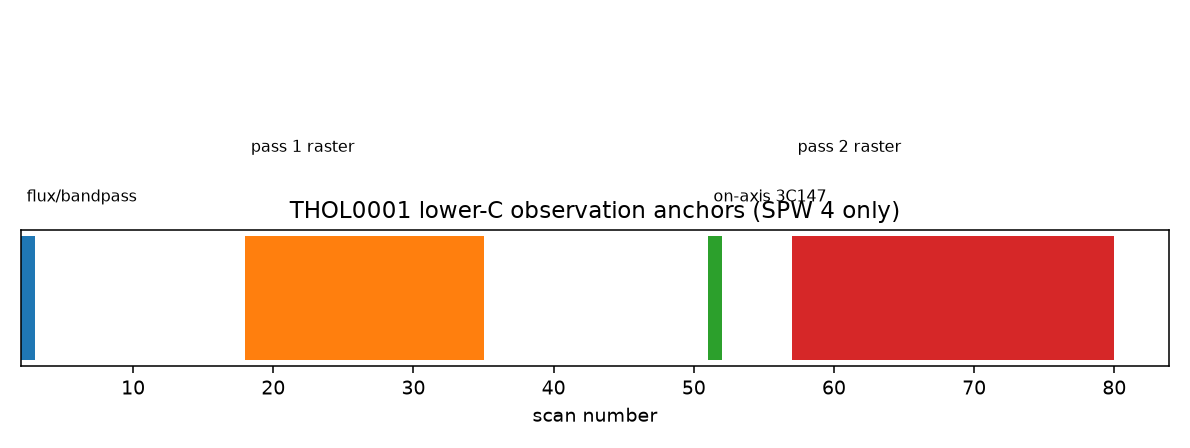

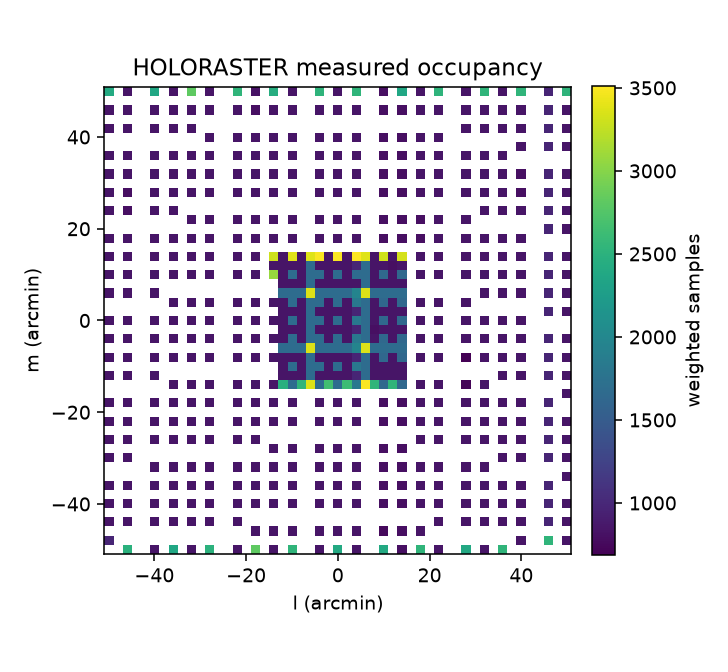

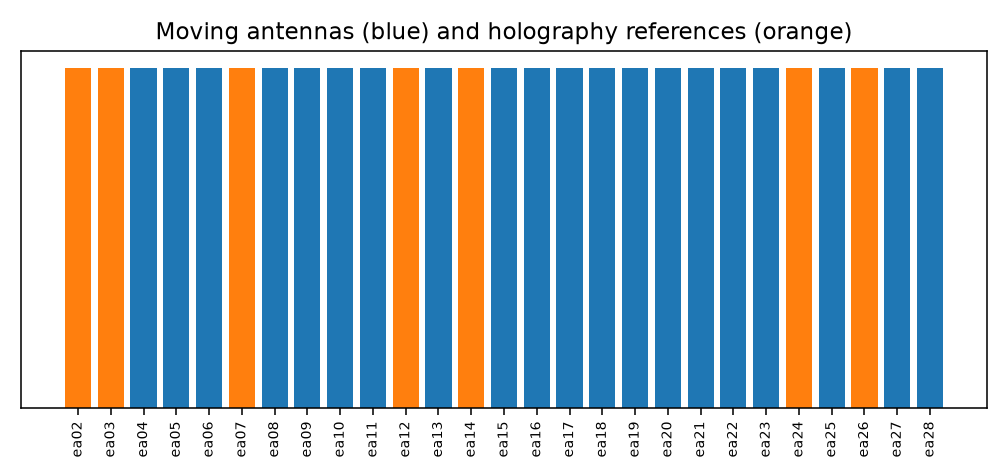

In [5]:
from IPython.display import Image, display

def show(*names):
    root = Path("docs/assets/vla_c_band_beam_validation")
    for name in names:
        display(Image(filename=str(root / name)))

show("01_observation_timeline.png", "02_raster_occupancy.png", "03_antenna_roles.png")


## 4. Calibration and source model

HOLORASTER field 10 already has `CORRECTED_DATA`. C147-* fields 1–8 were never applied on disk; those predictions start from `DATA`. Full-pol uses `parang=True`. The C147-* ring is unused prediction data.

In [6]:
cal = bundle.calibration
print("refant", cal["reference_antenna"], "calwt", cal["calwt"])
print("diagonal parang", cal["diagonal_parang"], "fullpol parang", cal["fullpol_parang"])
print("HOLORASTER apply from", cal["apply_holoraster_from"])
print("C147-* apply from", cal["apply_c147_offset_from"])
print("source model", cal["source_model"])
print("3C286", cal["three_c286"])


refant ea02 calwt False
diagonal parang False fullpol parang True
HOLORASTER apply from CORRECTED_DATA
C147-* apply from DATA
source model {'name': '3C147', 'kind': 'point', 'standard': 'Perley-Butler 2017'}
3C286 {'casaguide_two_chi_deg': 66.0, 'iau_evpa_deg': 33.0, 'residual_x_deg': -0.3824005126953125, 'v_over_i': -0.004271958488970995}


## 5. Convention and software correctness

These residuals lock CASA/JAX apply semantics. They are not evidence that CASSBEAM is physically correct. The Jones packing remains native; the 128-member convention search is closed.

In [7]:
gates = bundle.convention_gates
print("software gates passed", gates["software_gates_passed"])
print("convention", gates["cassbeam_convention"])
print("not physical beam evidence", gates["not_physical_beam_evidence"])
for name, row in (gates.get("cumulative_residuals") or {}).items():
    print(name, row.get("median_rel_l2"))


software gates passed True
convention {'l_sign': 1, 'm_sign': 1, 'swap_lm': False, 'jones': 'native', 'swap_rl': False, 'rotate_spatial': False, 'note': 'Locked mount-frame native packing. The 128-convention search is not reopened.'}
not physical beam evidence True
K+B+G 0.002857593215032758
K+B+G+Kcross 0.01640301260117932
K+B+G+Kcross+Df 0.02226890583604062
K+B+G+Kcross+Df+Xf 0.022268922893577053
K+B+G+Kcross+Df+Xf+P 0.01634986503966375


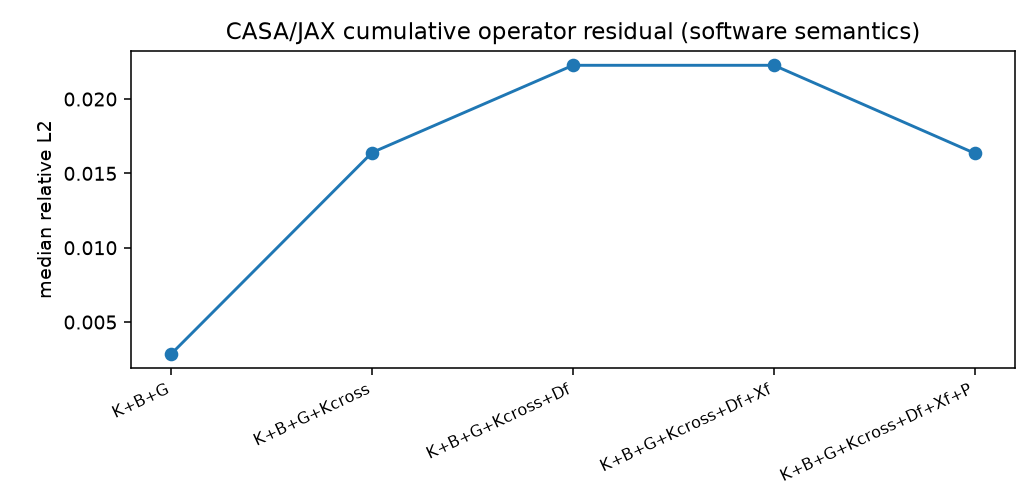

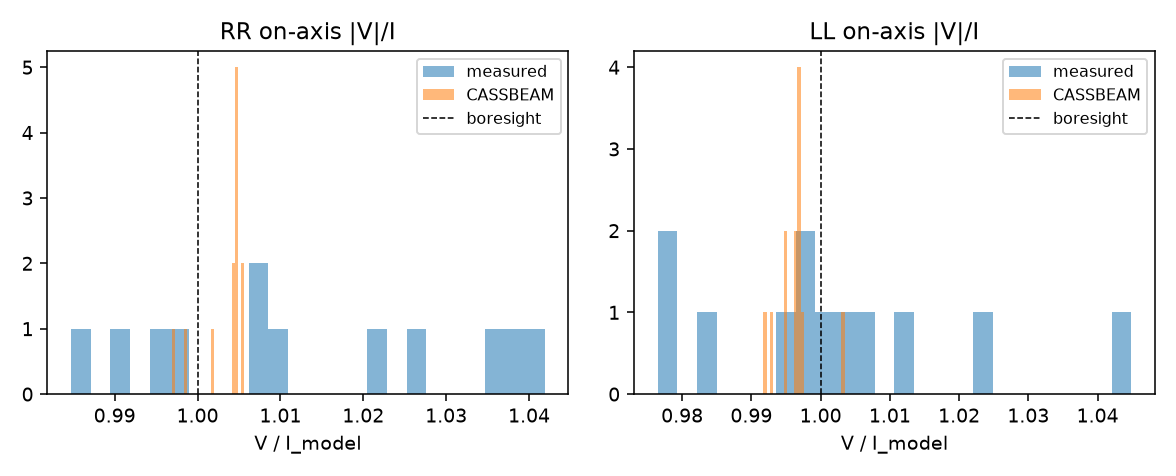

In [8]:
show("04_casa_jax_operator_residual.png", "05_onaxis_amplitude.png")


## 6. Corrected coordinate and EVLA-C feed update

The physical query coordinate is the source direction relative to the commanded antenna pointing, expressed on the CASSBEAM feed axes. For the HOLORASTER source at the phase centre this is

$$s_{\rm feed}=-\Delta_{\rm commanded}. $$

Three predictions are evaluated on exactly the same calibrated SPW-4 development rows: generic VLA at the historical commanded coordinate, generic VLA at the corrected source coordinate, and EVLA-C feed parameters at the corrected source coordinate. The paired spatial and mover holdouts separate the coordinate effect from the feed-parameter effect. These are development holdouts, not the still-sealed SPW-5 transfer test.

The corrected-frame squint vector uses the training-only independent-mask map estimate to compare direction. It does not replace the all-data publication squint magnitude in Section 10.

scope SPW-4 frozen development rows
coordinate {'commanded_offset_azelgeo': 'DIRECTION - TARGET = POINTING_OFFSET', 'source_lm_feed': 'negative commanded displacement; CASSBEAM query coordinate', 'axis_map': 'az_to_plus_l_el_to_plus_m_no_swap'}
interpretation {'keep_physical_squint': 1, 'native_orientation_retained_as_production_prior': 0, 'source_lm_feed_beats_commanded': 0, 'axis_map': 'az_to_plus_l_el_to_plus_m_no_swap', 'evla_c_compared': 1, 'spw5_ready': 0, 'development_only': 1, 'convention_ladder_reopened': 0, 'evla_c_beats_generic_source': 1}
updated EVLA-C/source-in-beam region metrics
all {'rr': 0.05299358705595033, 'll': 0.05207306447061701}
main_lobe {'rr': 0.00598024202606638, 'll': 0.0055334228002249415}
mid {'rr': 0.06017057265017186, 'll': 0.057538148290871324}
outer_diagnostic {'rr': 0.31018474366759113, 'll': 0.30816147370680436}
generic_source_lm_vs_generic_commanded
spatial delta 0.001191019715968883 95% CI (-0.005319307391281258, 0.009893888788282635) improves Fals

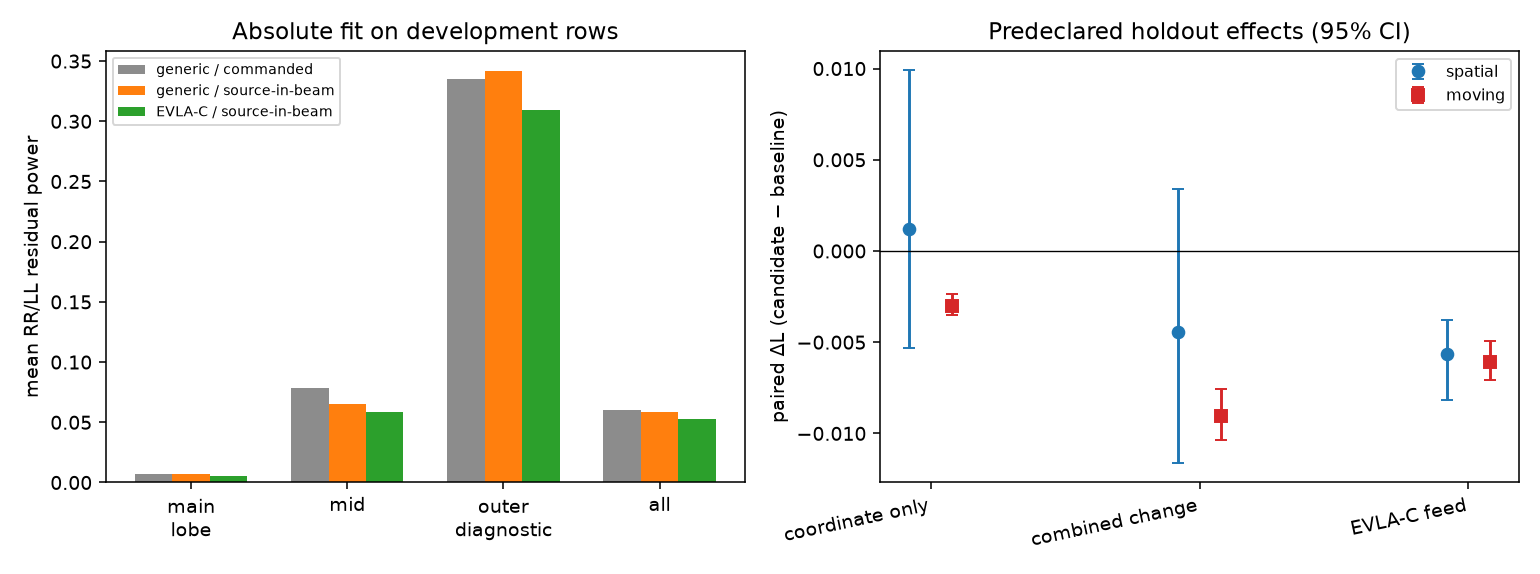

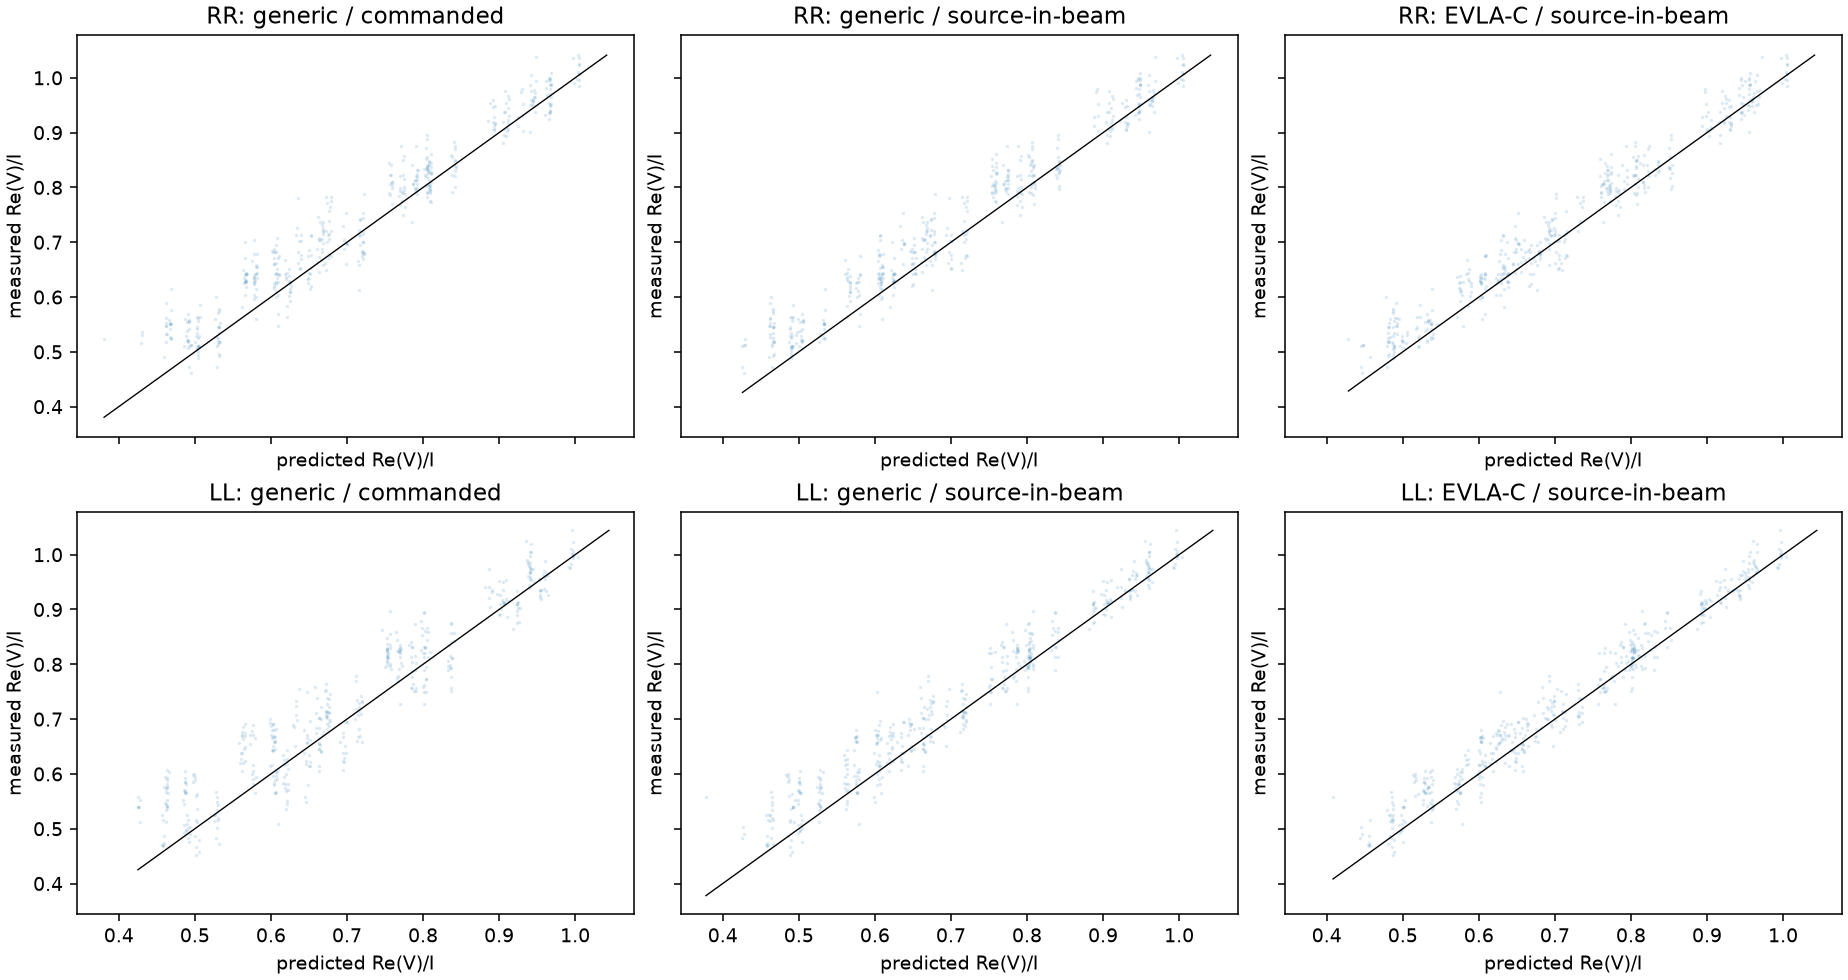

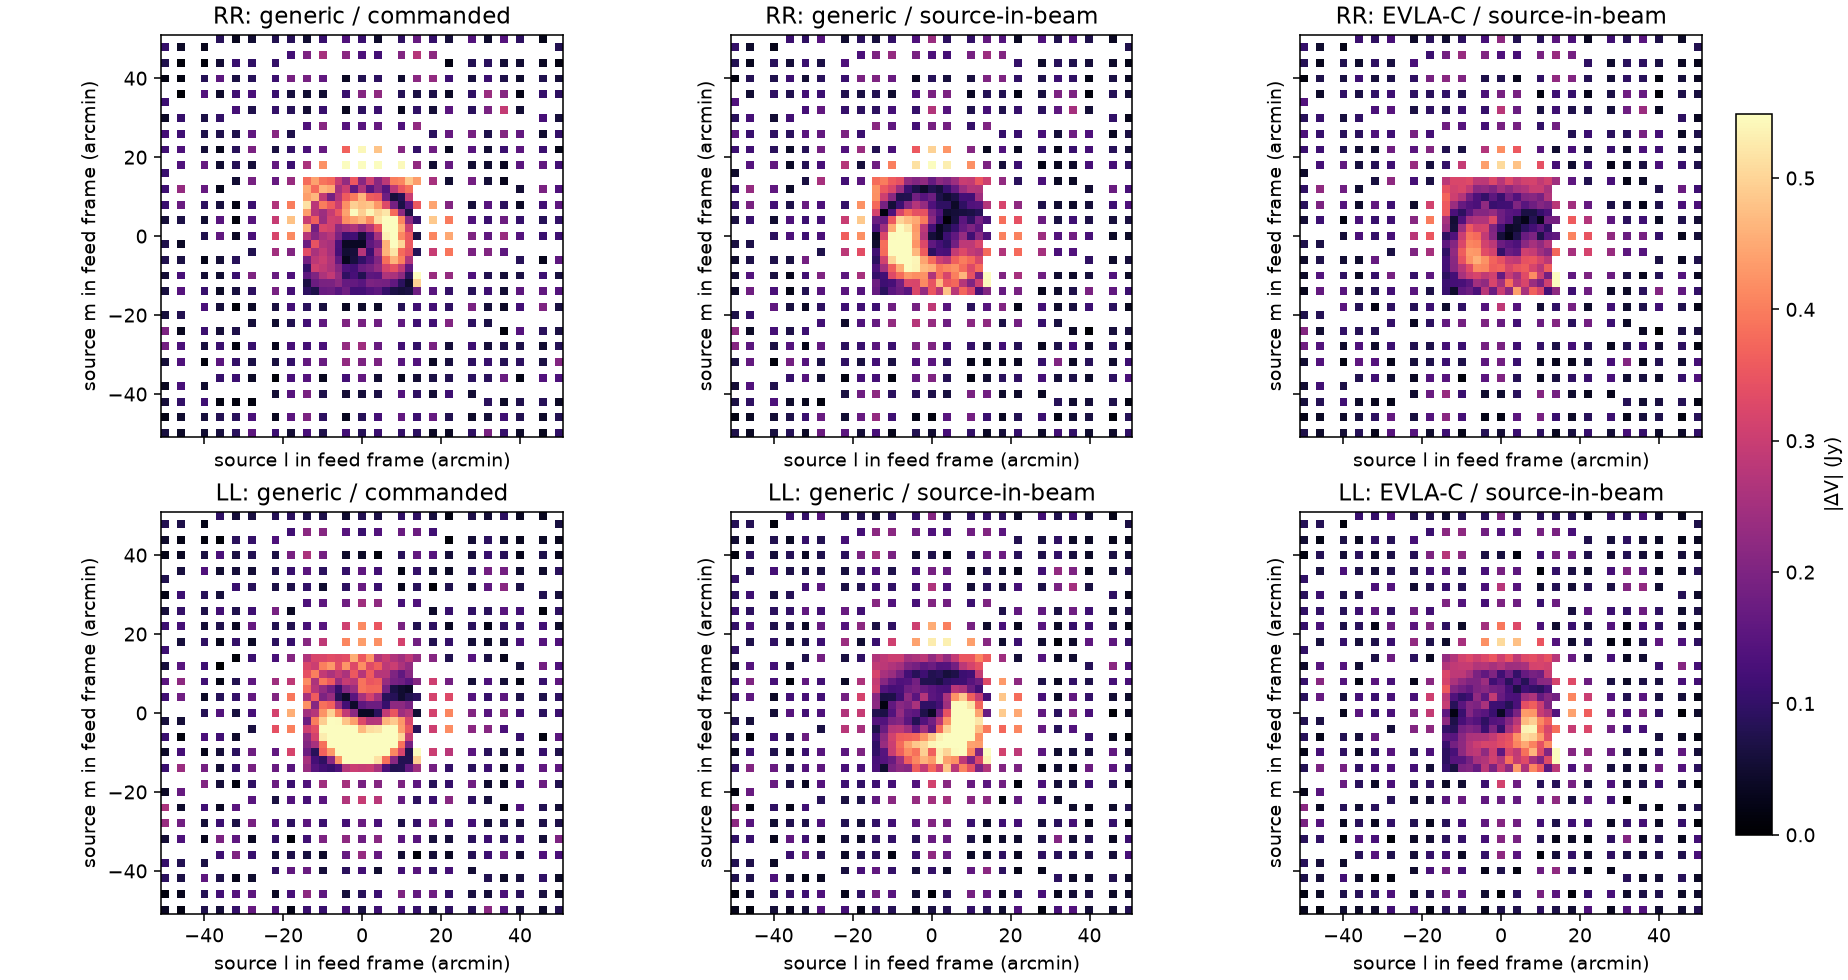

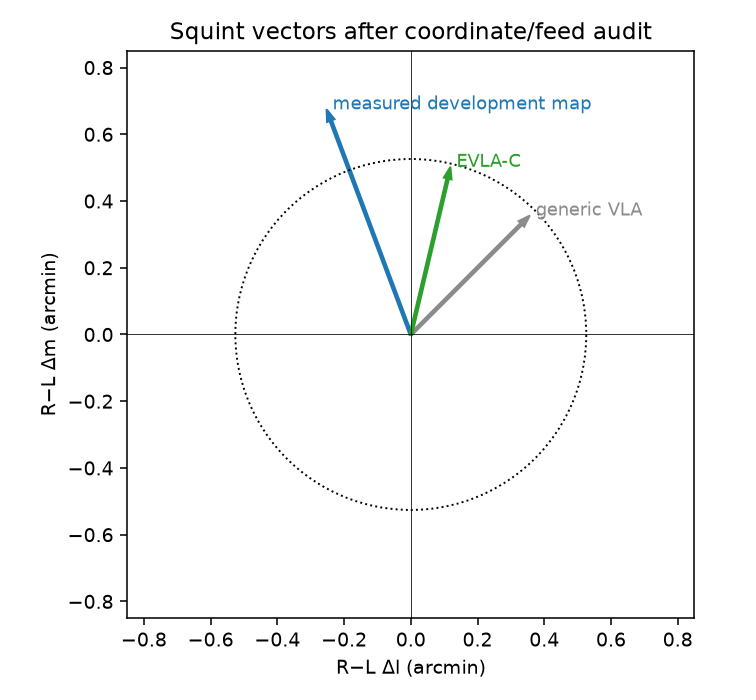

In [9]:
comparison = bundle.coordinate_feed_comparison
print("scope", comparison["scope"])
print("coordinate", comparison["coordinate_contract"])
print("interpretation", comparison["interpretation"])
print("updated EVLA-C/source-in-beam region metrics")
for region, hands in comparison["metrics"]["evla_c_source_lm"]["development"].items():
    print(region, {hand: row["residual_power"] for hand, row in hands.items()})
for name, score in comparison["paired_scores"].items():
    print(name)
    for axis in ("spatial", "moving"):
        row = score[axis]
        print(axis, "delta", row["delta"], "95% CI", (row["delta_lo"], row["delta_hi"]),
              "improves", bool(row["improves"]))
print("measured source-frame squint", comparison["map_squint"]["source_lm_labels"]["independent_masks"])
print("EVLA-C plane squint", comparison["evla_plane_centroids"])
show(
    "26_coordinate_feed_impact.png",
    "27_coordinate_feed_scatter.png",
    "28_coordinate_feed_residual_maps.png",
    "29_coordinate_feed_squint.png",
)


## 7–9. Direct HOLORASTER comparison (historical baseline)

These panels preserve the frozen generic-VLA comparison at commanded coordinates. The update in Section 6 supersedes that model as the leading SPW-4 development candidate. Every calibrated moving–reference visibility is compared without a fitted coefficient. The source is at the phase centre, so the geometric fringe is identically one.

On axis, $V_{mr}\simeq S$ with $E_m(0)=E_r(0)=1$. Flux calibration cannot remove an off-axis beam error without spoiling that on-axis agreement. Away from the origin, $\Delta V(s)\simeq S\,[E_{\mathrm{measured}}(s)-E_{\mathrm{CASSBEAM}}(s)]$. A 1 Jy residual on this 8 Jy calibrator is a voltage-beam error of about 0.125, not a missing flux-scale factor.

The quoted residual-power scores are not flux or amplitude errors. Their square roots are the RMS visibility errors. The notebook also reports median $|\Delta V|/I$. The publication scatter uses the same $V/I_{\mathrm{model}}$ main-lobe mask as the claimed metric.

Maps are visibility-domain binned means, not recovered $E$ interpolants. Unsupported cells are masked. Raster-family residuals are a Memo 195 dense/sparse occupancy proxy, not a scan-id join.

The measured raster reaches about $\pm 51'$ and $71'$ in the corners. High-resolution CASSBEAM covers essentially that whole field. Outer-beam CASSBEAM captures substantial coherent structure (complex correlation about 0.82), but residual power of 32--35% and a median amplitude ratio near 1.6 mean it is not yet an unqualified bright-source predictor. The first-null region near 20--30′ is poorly predicted; coherence partially returns in the next sidelobe. F24 shows the same radial degradation across the 20 movers.

The dB ratio is a diagnostic, not a multiplicative correction. When CASSBEAM predicts only 0.05--0.15 Jy and the residual floor is about 0.2 Jy, magnitude ratios are biased upward. A correction would need coherent complex averaging, uncertainty propagation, and transfer across held-out antennas and cells. Phase means are exploratory and must not be read as a general outer phase correction.

For a common scalar beam, $E_p(s)E_q(s)^{*}=|E(s)|^{2}$, so a shared voltage phase—and even a shared $\pi$ lobe sign—cancels in ordinary Stokes I. Outer-lobe magnitude is the main imaging concern. Phase matters when antenna beams differ, for R/L differences and cross-polar terms, and for antenna-dependent Jones beams.

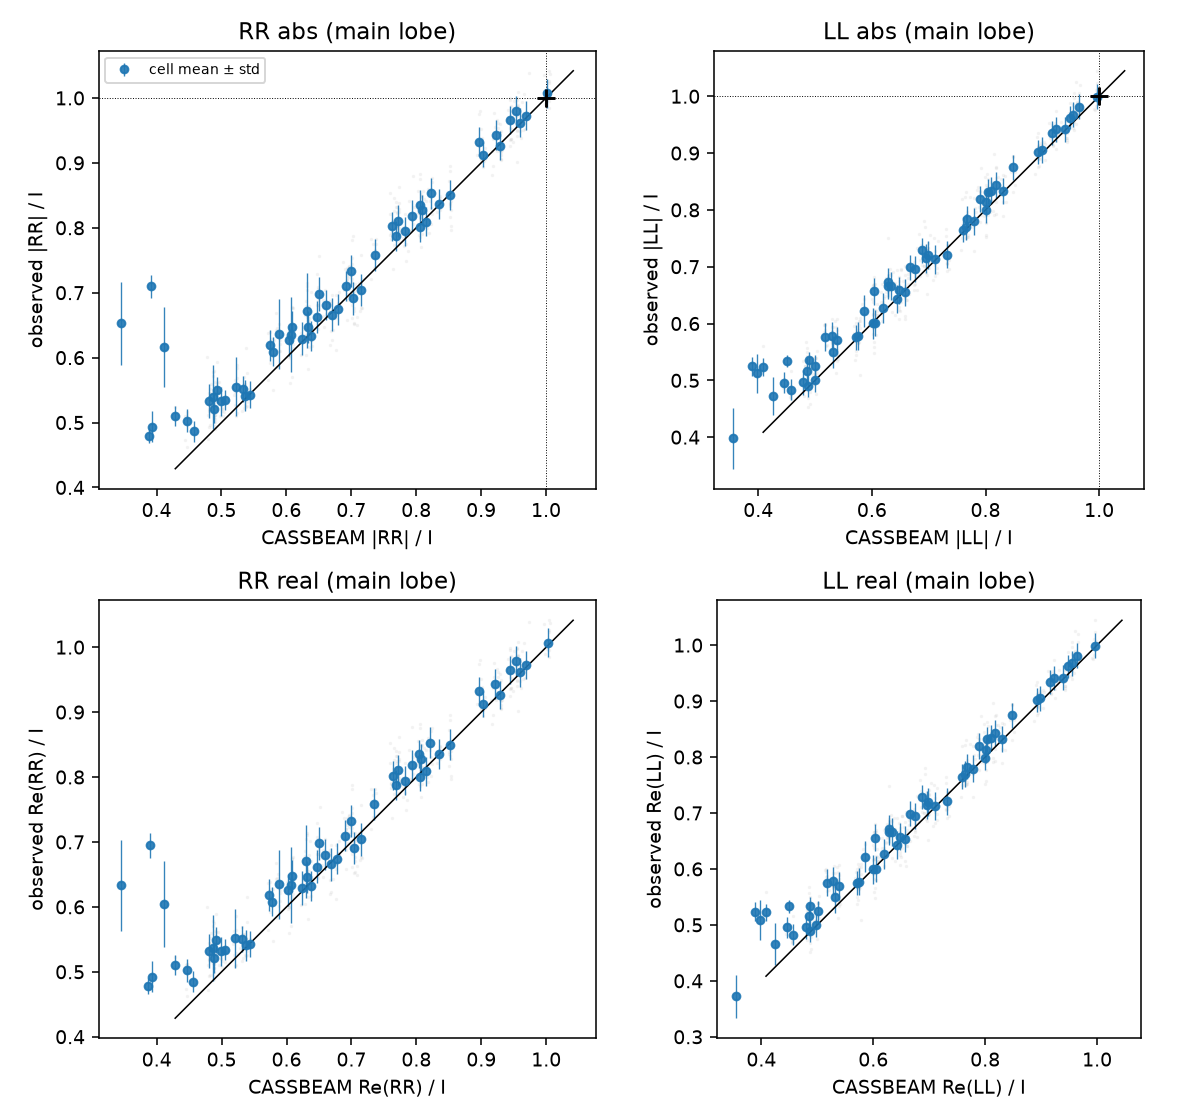

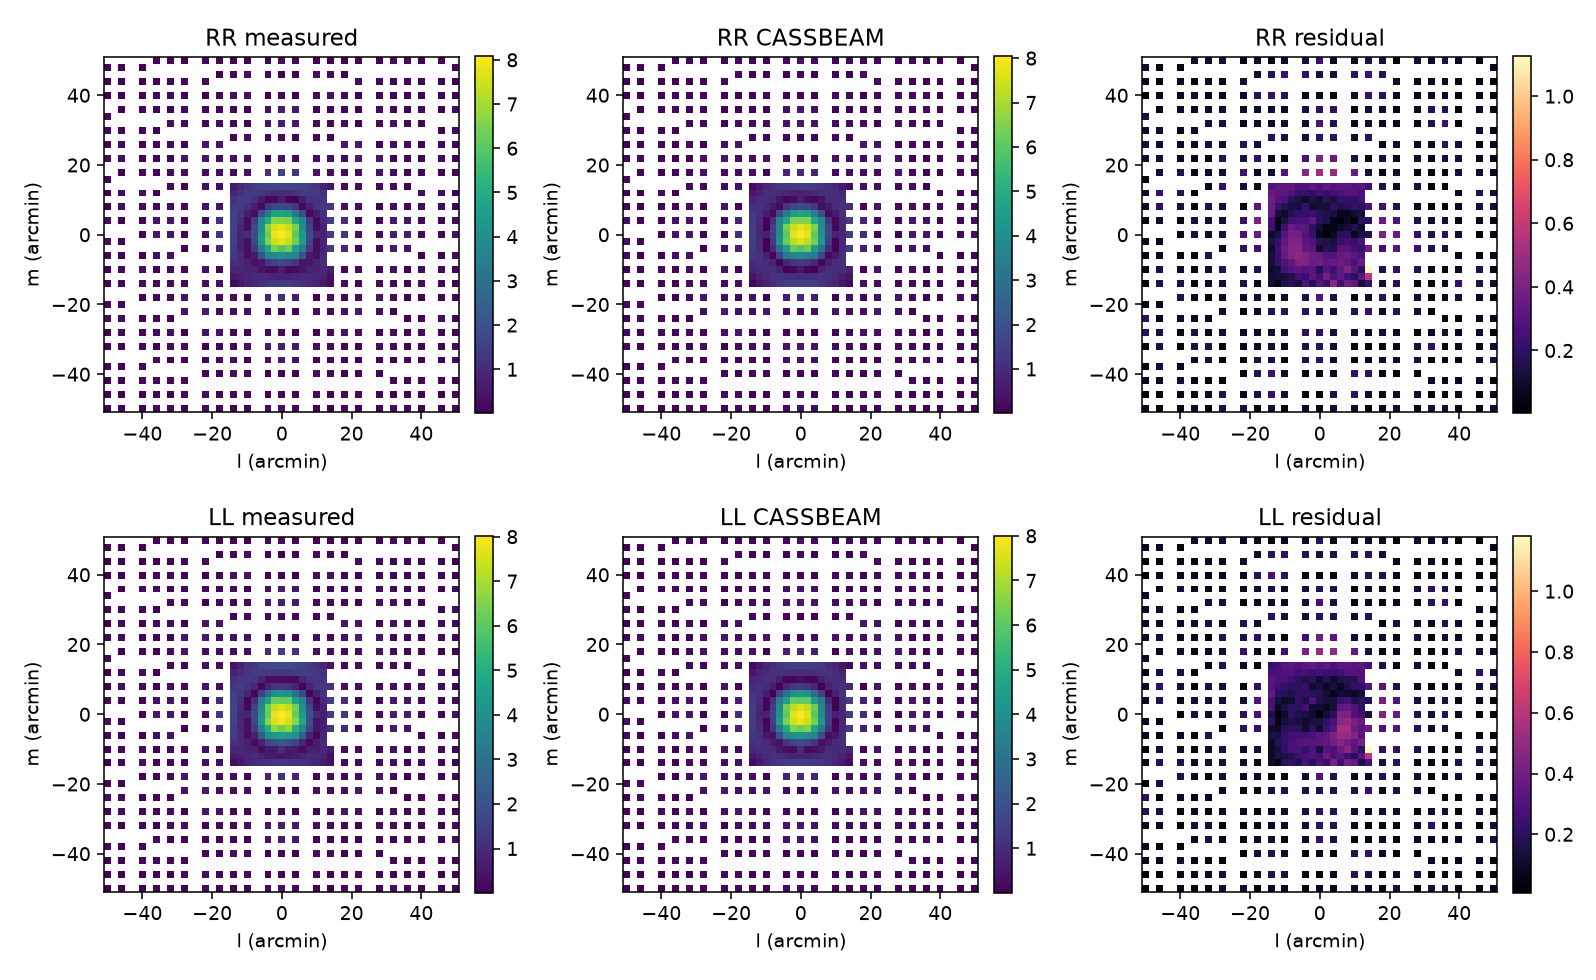

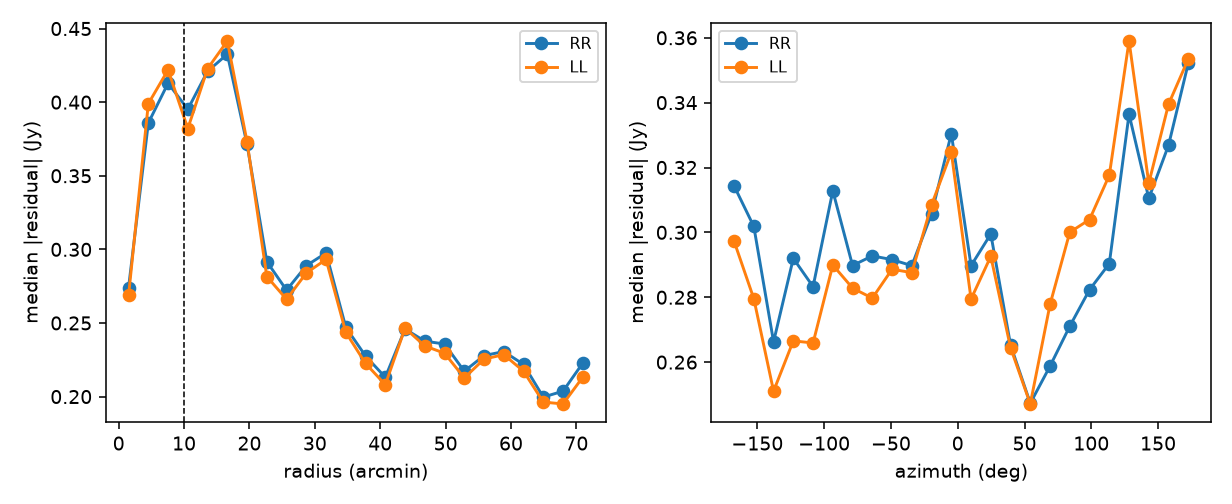

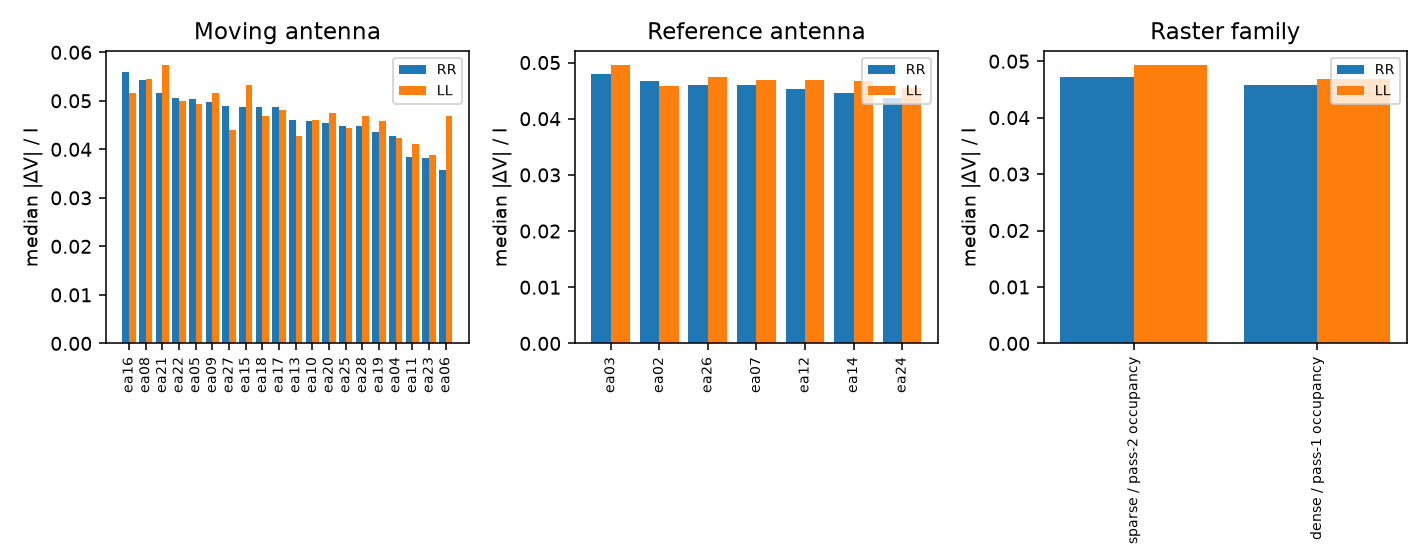

mask V/I_model using CASA MODEL_DATA 3C147 at channel 32
raster_family Nearest Memo 195 dense versus sparse lattice. This is a pass-1/pass-2 occupancy proxy, not a scan-id join.
mover [('ea16', 1818, 0.4494040903493832), ('ea08', 772, 0.43521223206678855), ('ea21', 1908, 0.41493209134055575), ('ea22', 736, 0.40679129613246257), ('ea05', 1859, 0.40493355553800486), ('ea09', 1868, 0.3998928843305544), ('ea27', 1841, 0.39242235833635974), ('ea15', 1883, 0.39193239333089047)]
reference [('ea03', 5380, 0.38572759266960543), ('ea02', 5398, 0.3753600110707638), ('ea26', 2253, 0.36954208289388657), ('ea07', 5364, 0.3688915031186135), ('ea12', 5402, 0.3636587446167871), ('ea14', 5389, 0.35801740848183794), ('ea24', 2247, 0.35012878555019245)]
pass [('sparse / pass-2 occupancy', 3552, 0.3783536237302516), ('dense / pass-1 occupancy', 27881, 0.36723494086040337)]


In [10]:
show(
    "08_cassbeam_scatter_main_lobe.png",
    "10_spatial_measured_cassbeam_residual.png",
    "12_residual_vs_radius.png",
    "15_residual_strata.png",
)
strata = bundle.residual_strata
print("mask", strata.get("mask"))
print("raster_family", strata.get("raster_family"))
for key in ("mover", "reference", "pass"):
    print(key, [(row.get("name"), row.get("n"), row.get("median_abs")) for row in strata.get(key) or ()][:8])


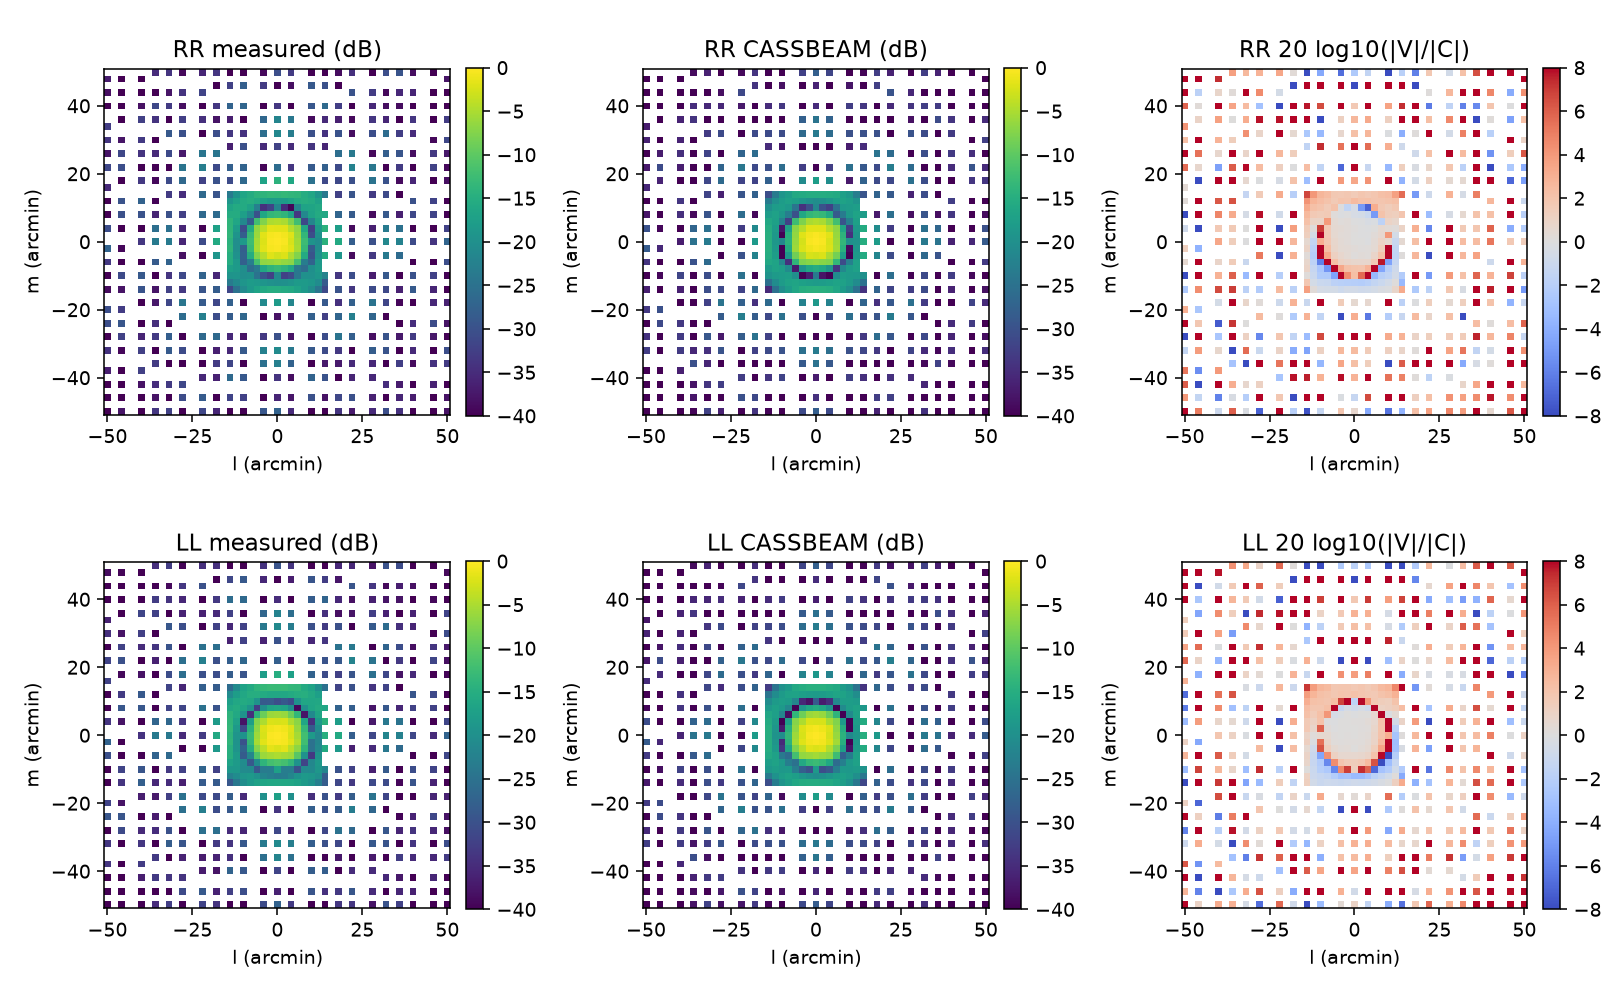

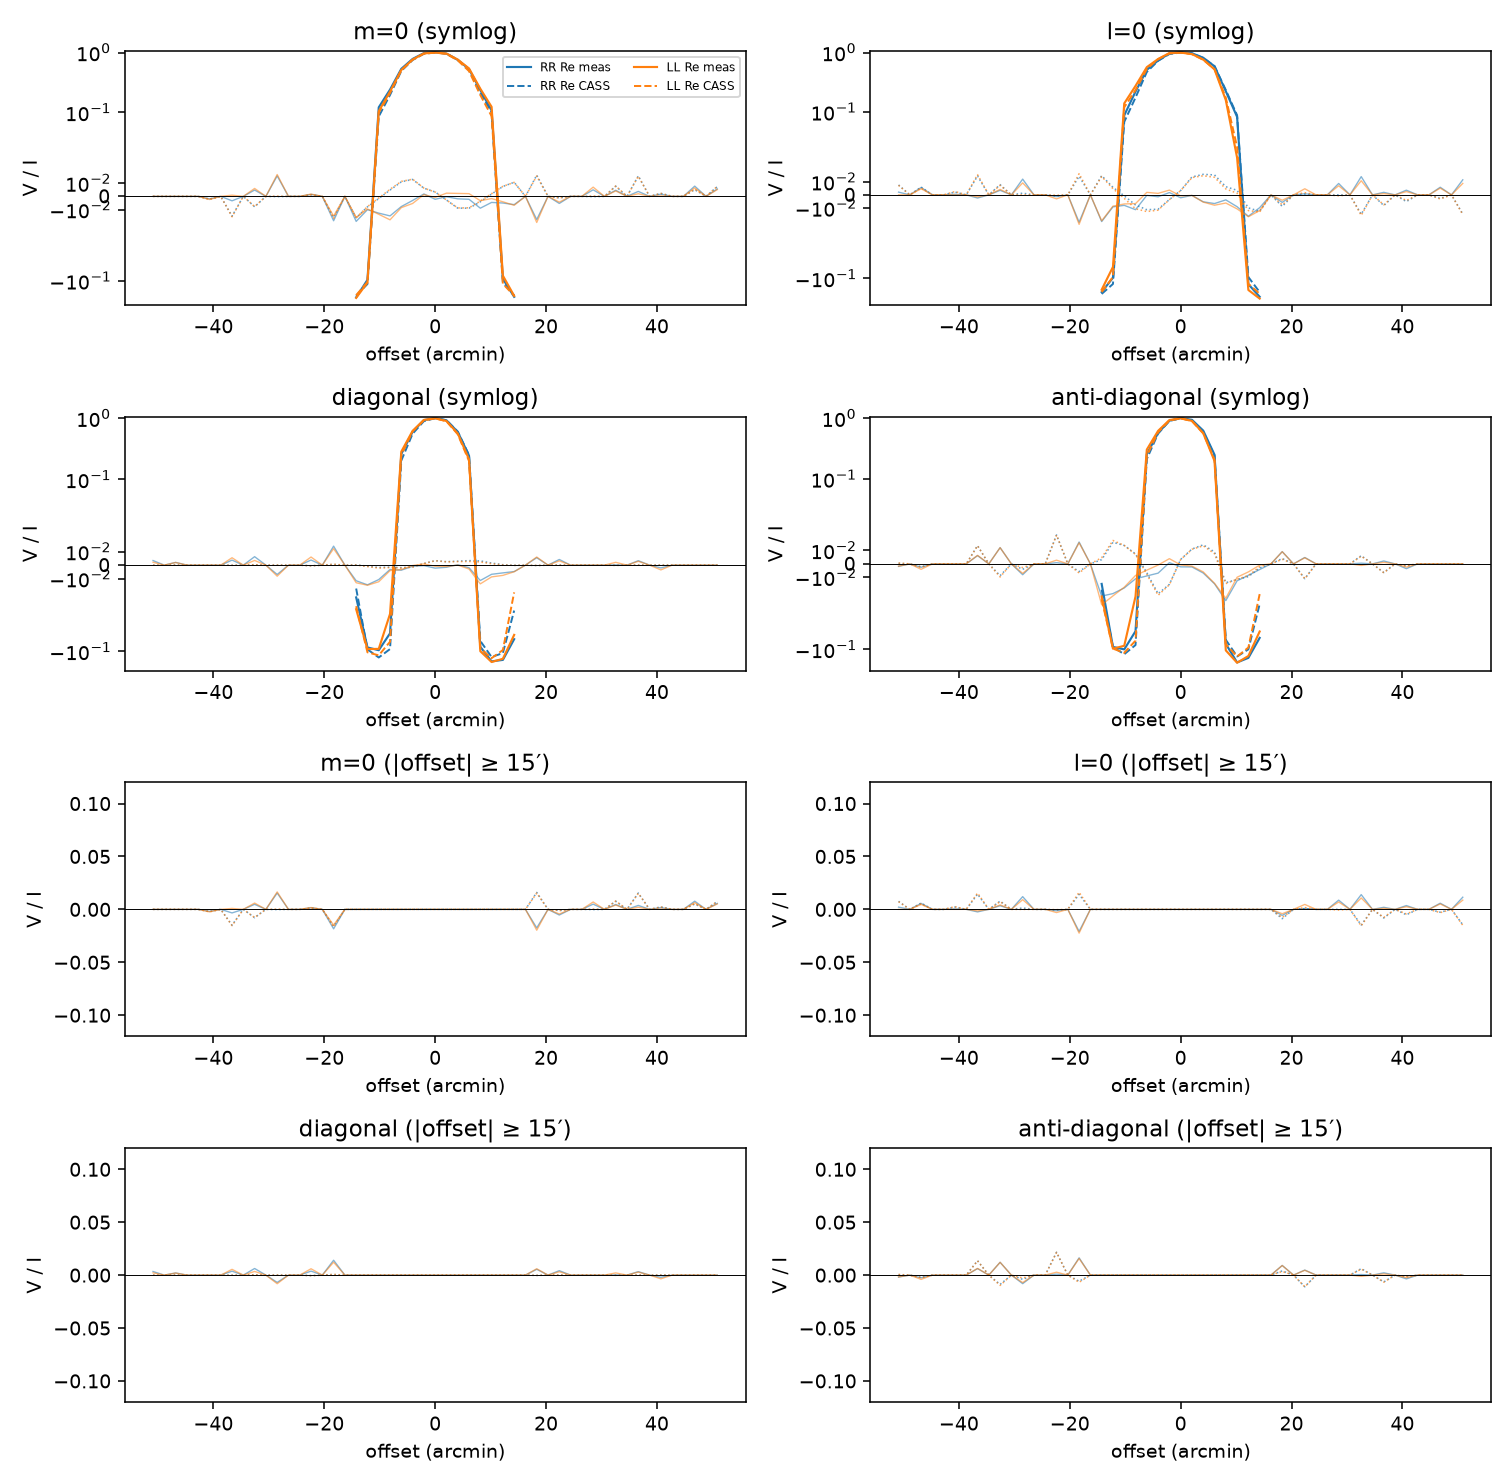

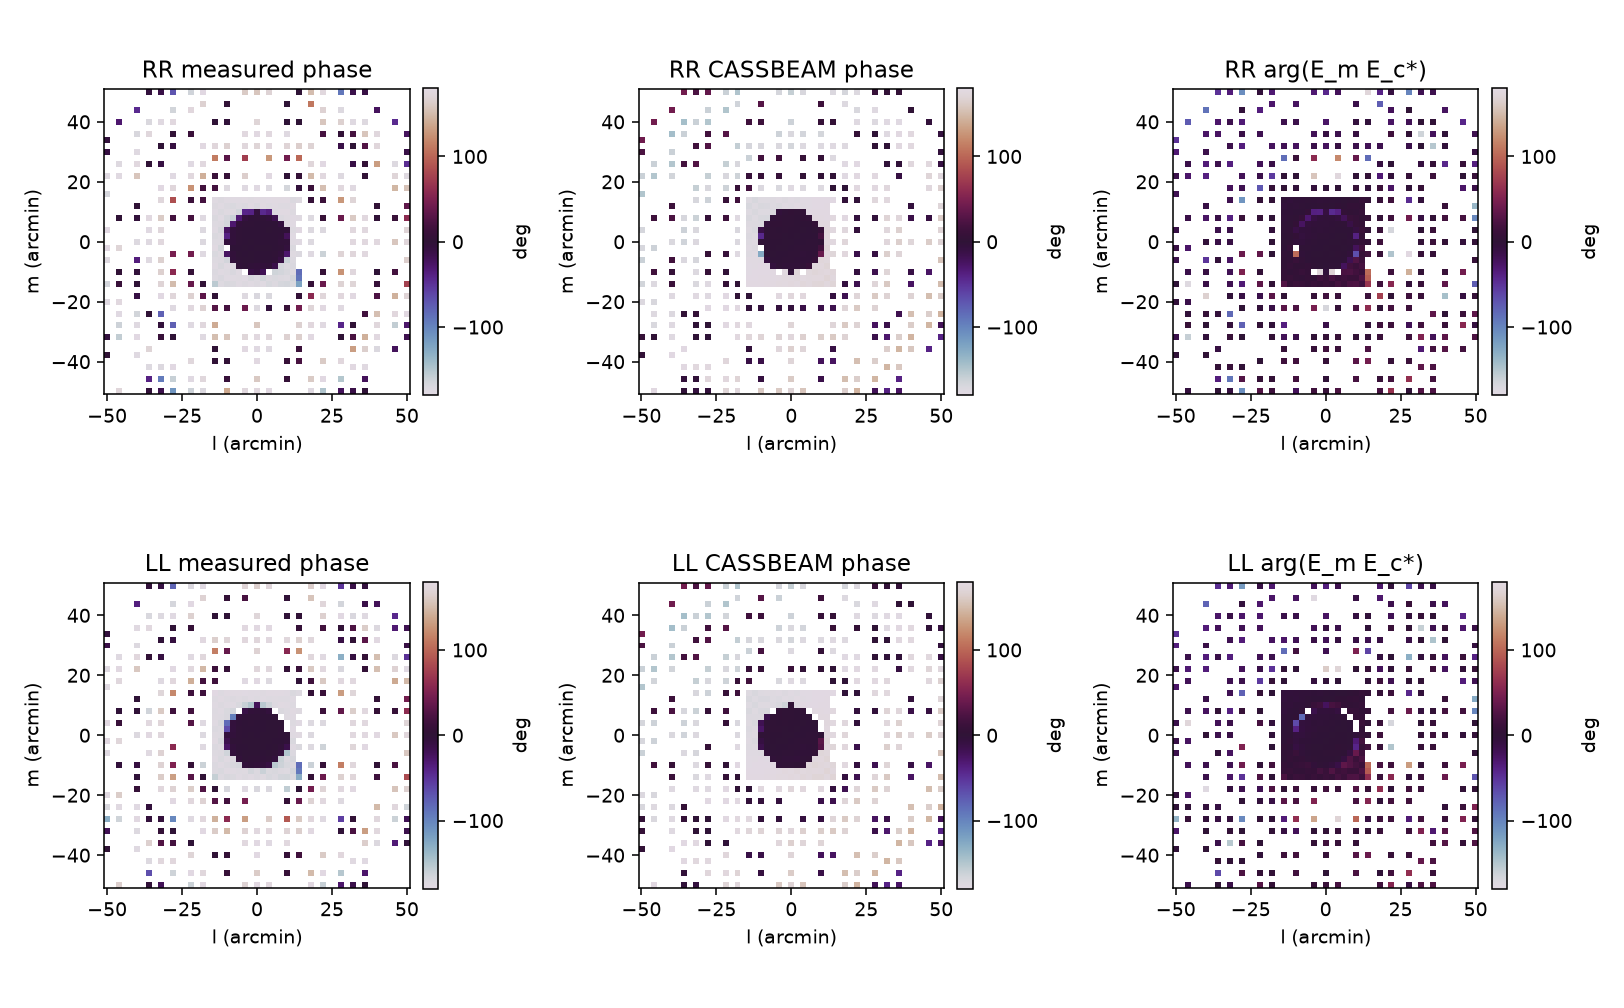

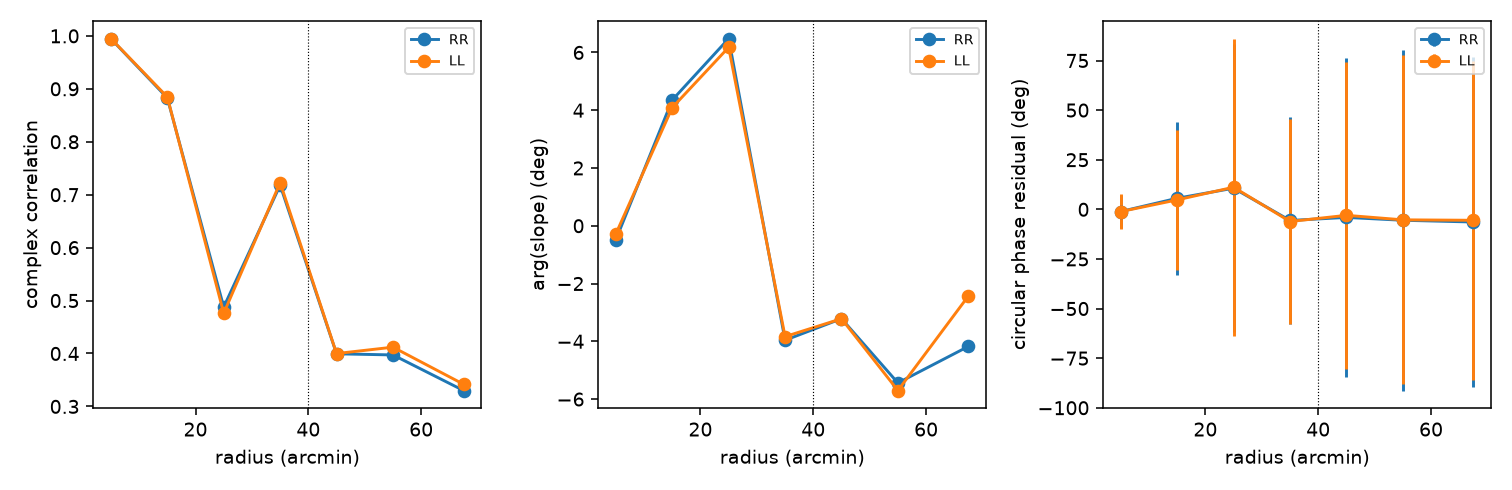

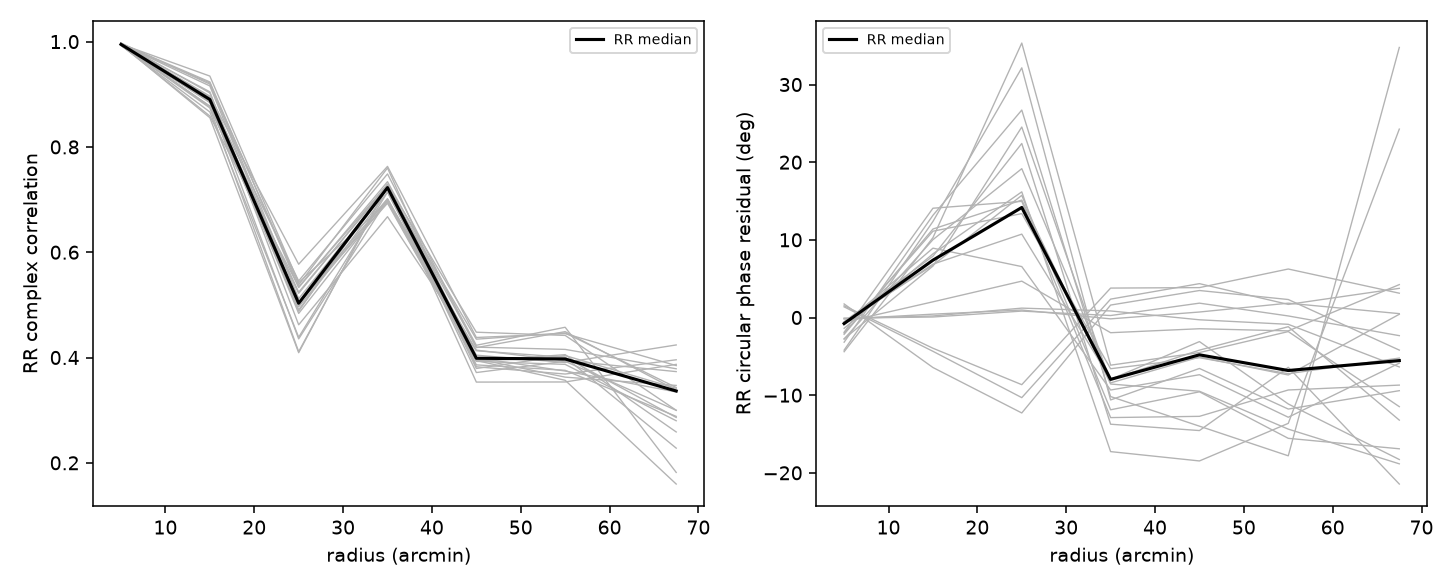

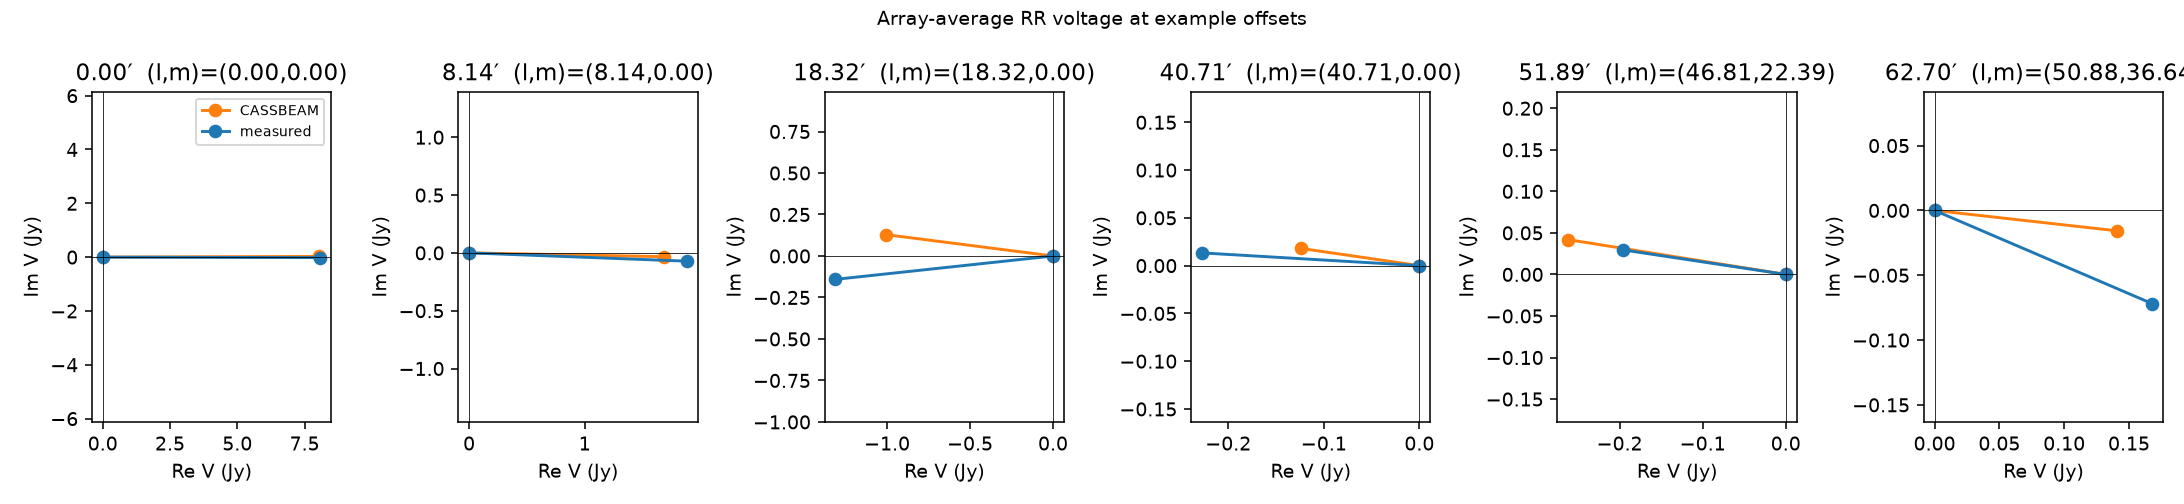

phase_status exploratory amp_floor_jy 0.05
extent {'l_abs_max': 50.60659700195147, 'm_abs_max': 51.90152170783606, 'corner_max': 72.48996906956783}
map phase >40' {'rr': {'n': 184.0, 'slope_real': 1.0472680551179518, 'slope_imag': -0.07374923920010597, 'correlation_abs': 0.8351287782449504, 'residual_power': 0.3074152724746225, 'median_abs_obs': 0.1676974428894721, 'median_abs_pred': 0.13910407165593447, 'median_abs_ratio': 1.2055538050982548, 'median_phase_deg': -5.991816385204632, 'circular_phase_deg': -8.526427082006988, 'circular_phase_std_deg': 38.29781398955779}, 'll': {'n': 185.0, 'slope_real': 1.0597524477357723, 'slope_imag': -0.07269058194311051, 'correlation_abs': 0.8371291685955841, 'residual_power': 0.3047138425516753, 'median_abs_obs': 0.1657604804468865, 'median_abs_pred': 0.1379396182773799, 'median_abs_ratio': 1.2016886991347344, 'median_phase_deg': -6.1120875912532755, 'circular_phase_deg': -7.260386931216977, 'circular_phase_std_deg': 35.18872198655097}}
rr [(5.0, 0.

In [11]:
show(
    "20_amplitude_db.png",
    "21_signed_complex_cuts.png",
    "22_masked_phase.png",
    "23_radial_coherence.png",
    "24_antenna_coherence.png",
    "25_bright_source_examples.png",
)
coh = bundle.radial_coherence
print("phase_status", coh.get("phase_status"), "amp_floor_jy", coh.get("amp_floor_jy"))
print("extent", coh.get("raster_extent_arcmin"))
print("map phase >40'", coh.get("map_phase_beyond_40_arcmin"))
for hand in ("rr", "ll"):
    print(hand, [(row["r_mid_arcmin"], row["correlation_abs"], row["circular_phase_deg"]) for row in coh.get(hand) or ()])
print("movers", [row["name"] for row in bundle.antenna_coherence.get("movers") or ()])
print("examples", [row.get("label") for row in bundle.bright_source_examples.get("examples") or ()])


## 10. R/L squint

The publication estimator is the 20%-of-peak main-lobe power centroid, with independent RR and LL flags and weights. The full-raster centroid is a bias diagnostic only. Section 6 compares explicitly named R-minus-L vectors in the corrected source/feed frame.

measured sep 0.5260404092653528 memo 0.525854513584575 full_raster 0.38814396932165063 n 33161 32307
cassbeam sep 0.47604180753320846 memo 0.525854513584575 full_raster 0.41540547388170734 n 33534 33360


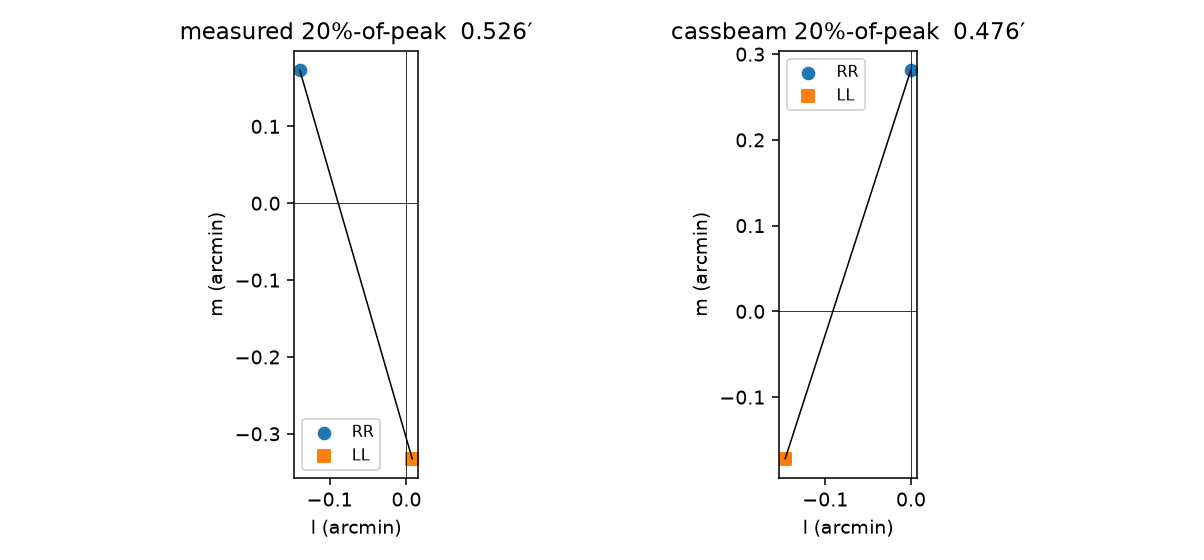

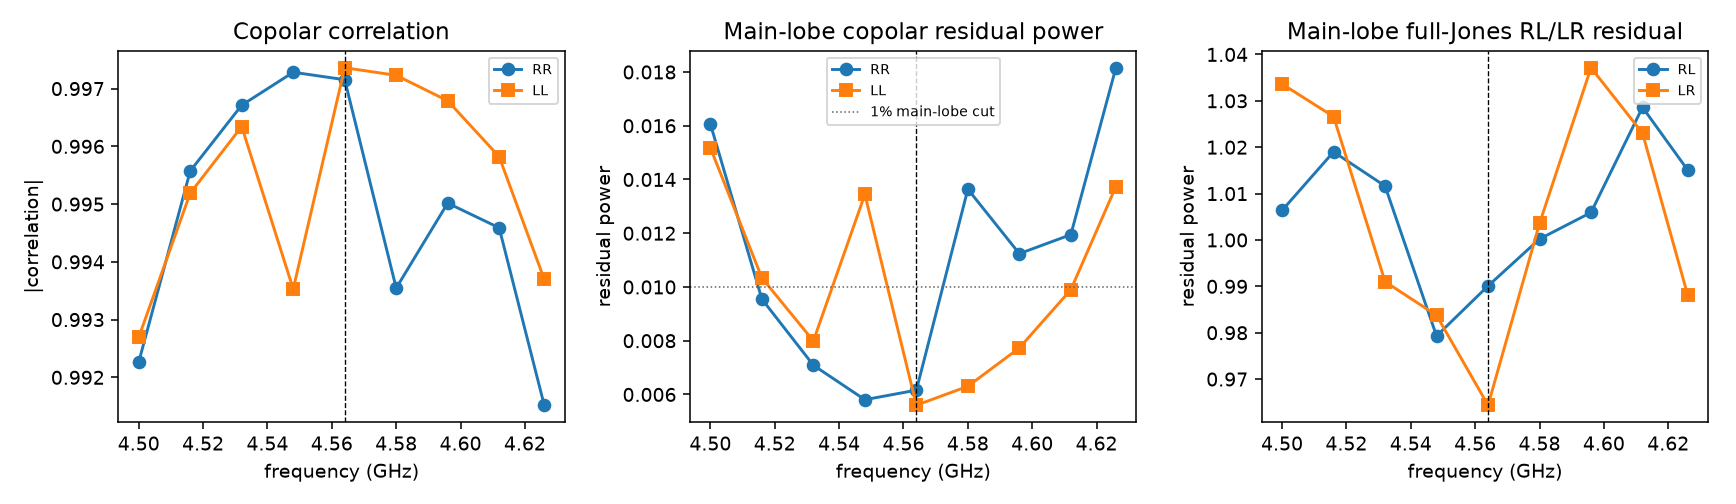

In [12]:
squint = publication_squint_pair(bundle.squint)
for name, row in squint.items():
    print(name, "sep", row["separation_arcmin"], "memo", row.get("memo195_separation_arcmin"),
          "full_raster", row["full_raster_separation_arcmin"], "n", row.get("n_rr"), row.get("n_ll"))
show("13_squint_mainlobe_20pct.png", "16_spw4_frequency.png")


## 11. C147-* offset ring

Fields 1–8 were unused prediction data. Offsets come from `FIELD.PHASE_DIR`. The CASA fringe $\exp(+2\pi i[ul+vm+w(n-1)])$ is required. The already-written ring Q/U used all 64 channels and is not a frequency holdout.

{'rr': 0.009084030947264246, 'll': 0.005506648850203247, 'passed': True, 'n_rr': 30888, 'n_ll': 30888, 'radius_arcmin': 3.6134405474883557, 'q_u_is_frequency_holdout': False}
channel-32 closure {'rr': {'relative_power': 0.009084030947264246, 'n': 30888, 'ok': 1}, 'll': {'relative_power': 0.005506648850203247, 'n': 30888, 'ok': 1}, 'passed': True, 'partition': 'inner_holdout', 'channel': 32}
empty inner-holdout channels [-1, 63]
historical_holdout True
Q/U is frequency holdout False


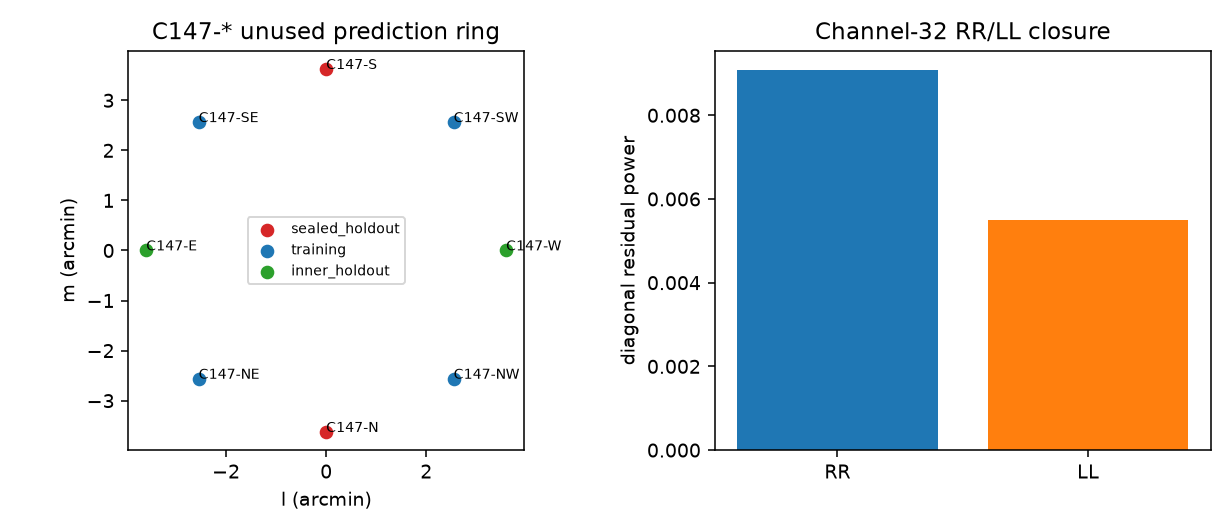

In [13]:
ring = offset_ring_diagonal_closure(bundle.offset_ring)
print(ring)
print("channel-32 closure", bundle.offset_ring.get("closure"))
print("empty inner-holdout channels", bundle.offset_ring.get("empty_inner_holdout_channels"))
print("historical_holdout", bundle.offset_ring.get("historical_holdout"))
print("Q/U is frequency holdout", ring["q_u_is_frequency_holdout"])
show("17_c147_offset_ring.png")


## 12. Frequency transfer

This section is `not_run`. SPW 5 at 4.692 GHz remains sealed.

SPW 5 section status: not_run


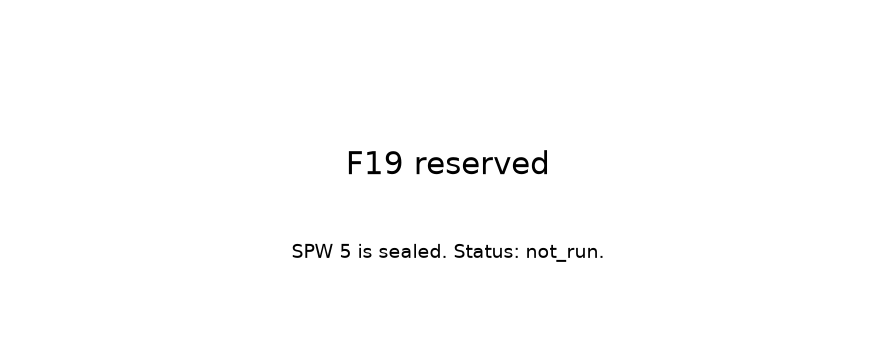

In [14]:
print("SPW 5 section status: not_run")
show("19_spw5_sealed.png")


## 13. Experimental full Jones

The current cross-hand panel compares EVLA-C diagonal and full Jones at `source_lm_feed`. The diagonal prediction is the null. Paired loss is candidate minus diagonal; negative is better. The bounded outcomes are `supported_on_spw4_development`, `disfavoured_on_tested_support`, `inconclusive_sensitivity`, and `blocked_implementation_or_contract`. Absence of improvement is not by itself a disfavour. Residual Jones is the channel-32 field-9 plane applied to all publication channels. Historical generic/commanded cross-hand scores are appendix controls.

{'rl_correlation': 0.10340211362728197, 'lr_correlation': 0.10539555292253826, 'rl_residual_power': 0.9932619890712673, 'lr_residual_power': 0.99375457916228, 'rl_median_abs_obs': nan, 'lr_median_abs_obs': nan, 'rl_median_abs_pred': nan, 'lr_median_abs_pred': nan}
predicted RL median nan observed nan


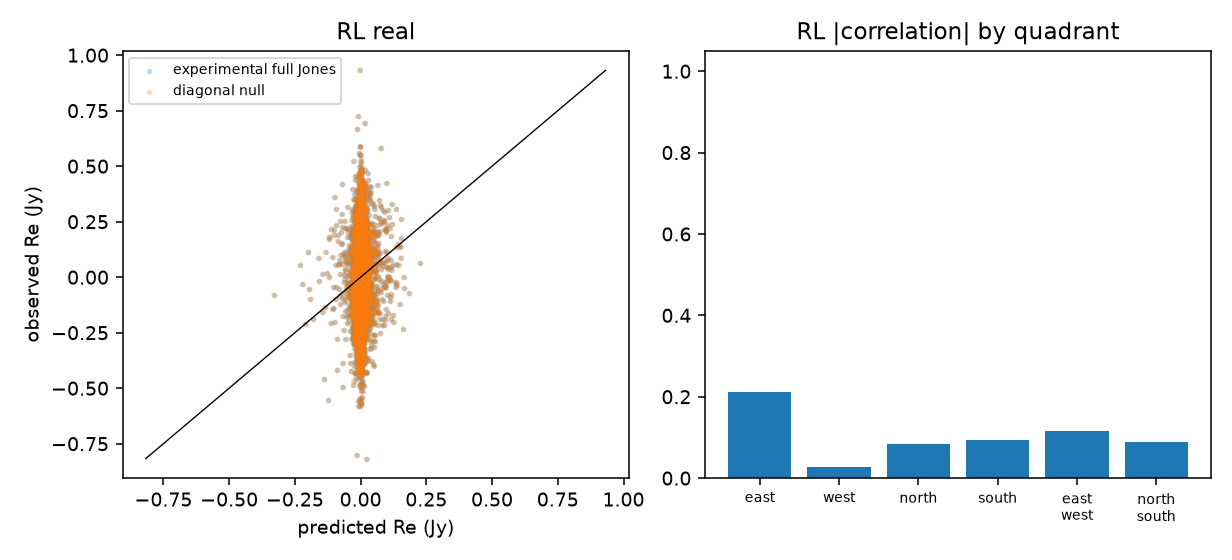

In [15]:
cross = crosshand_non_detection(bundle.holoraster_channel32)
print(cross)
print("predicted RL median", cross["rl_median_abs_pred"], "observed", cross["rl_median_abs_obs"])
show("18_experimental_crosshand.png")


## 14. Conclusions and limitations

Use EVLA-C CASSBEAM at `source_lm_feed` as the leading SPW-4 diagonal development model. Keep the generic VLA artifact as an ablation. Trust the main beam most strongly. Treat the mid beam as qualified. Attach substantial model uncertainty outside it. Keep explicit bright out-of-field source terms, because CASSBEAM alone can misestimate their apparent flux by factors of roughly two or more at particular outer locations. Do not infer a general outer phase correction from the current phase means.

The next bounded full-Jones step is a residual-Jones frequency axis; do not retune the current gates. The next diagonal step remains a validation-selected low-order correction or a sealed frequency-transfer test. Outer-field corrections should be admitted only if they transfer across movers and spatial holdouts; otherwise bright outer sources should get source-specific nuisance terms or peeling rather than a globally corrected beam. Full Jones is classified from the bundle outcome and is not a production acceptance. SPW 5 remains sealed.

In [16]:
print("next artifact: cassbeam_diagonal_low_order_correction")
print("convention search reopened", bundle.convention_gates.get("cassbeam_convention", {}).get("note"))
for row in claim_table(bundle):
    print(row["id"], row["status"], row["evidence"])


next artifact: cassbeam_diagonal_low_order_correction
convention search reopened Locked mount-frame native packing. The 128-convention search is not reopened.
C01 pass HOLORASTER channel-32 residual power RR 0.62%, LL 0.56% (RMS visibility 7.85% / 7.48%; median |ΔV|/I 4.55% / 4.68%)
C02 warn HOLORASTER mid-beam residual power RR 4.03%, LL 3.77%
C03 warn HOLORASTER outer residual power RR 29.53%, LL 28.98%; complex correlation 0.842 / 0.845; median |V| ratio nan / nan. Outer phase is exploratory and is not a claim metric.
C04 pass 3.61′ ring RR/LL residual power 0.91% / 0.55% after the geometric fringe
C05 warn The experiment cannot distinguish the unit full-Jones prediction from the diagonal at the predeclared sensitivity.
C06 not_run Reserved for one diagonal frequency-transfer test after a frozen SPW-4 correction
C07 pass Channel 32 measured 0.526′, Memo 195 0.526′, CASSBEAM 0.476′. The superseded full-raster measured centroid is retained only as a bias diagnostic
C08 pass POINTING_O